<a href="https://colab.research.google.com/github/sashkodr/Def-4-OOP/blob/main/LAB8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Лабораторна робота №8
## Оптимізація нейронних мереж для покращення класифікації


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split

from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization

import tensorflow as tf


## Завантаження даних

In [2]:

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"

columns = [
    'age', 'workclass', 'fnlwgt', 'education',
    'educational-num', 'marital-status',
    'occupation', 'relationship', 'race',
    'gender', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country',
    'income_>50K'
]

data = pd.read_csv(
    url,
    names=columns,
    skipinitialspace=True
)

print(data.head())
print(data.info())


   age         workclass  fnlwgt  education  educational-num  \
0   39         State-gov   77516  Bachelors               13   
1   50  Self-emp-not-inc   83311  Bachelors               13   
2   38           Private  215646    HS-grad                9   
3   53           Private  234721       11th                7   
4   28           Private  338409  Bachelors               13   

       marital-status         occupation   relationship   race  gender  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income_>50K  
0          2174             0              40  United-States       <=50K  
1             0     

## Очищення даних

In [3]:

clear_data = data.dropna(
    subset=["workclass", "occupation", "native-country"]
)

print(clear_data.isnull().sum())


age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income_>50K        0
dtype: int64


## Балансування класів

In [4]:

class0 = clear_data[clear_data['income_>50K']=="<=50K"].sample(n=10500)
class1 = clear_data[clear_data['income_>50K']==">50K"]

balanced_data = pd.concat([class0, class1])

print(balanced_data['income_>50K'].value_counts(normalize=True))


income_>50K
>50K     0.52675
<=50K    0.47325
Name: proportion, dtype: float64


## Факторизація

In [5]:

to_factor = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'gender',
    'native-country'
]

factor_data = balanced_data.copy()

factor_data[to_factor] = factor_data[to_factor].apply(
    lambda col: pd.factorize(col, sort=True)[0]
)

final_data = factor_data.drop('education', axis=1)

print(final_data.head())


       age  workclass  fnlwgt  educational-num  marital-status  occupation  \
38013   25          4  238605                9               4          12   
38313   26          6  109162                9               2           4   
19751   35          4  261646                9               2          11   
22318   32          4  157289                9               3           6   
45468   31          4  118551                9               4          13   

       relationship  race  gender  capital-gain  capital-loss  hours-per-week  \
38013             3     4       0             0             0              25   
38313             0     4       1             0             0              25   
19751             0     4       1             0             0              55   
22318             2     4       1             0             0              40   
45468             1     4       0             0             0              40   

       native-country income_>50K  
38013   

## Формування вибірок

In [6]:

Y = pd.get_dummies(final_data['income_>50K'], prefix='Class')

X = final_data.drop(['income_>50K'], axis=1)

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.15
)


## Нормалізація

In [7]:

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train -= mean
X_train /= std

X_test -= mean
X_test /= std


## Побудова моделі

In [8]:

early = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5
)

model = Sequential()

model.add(Dense(6, input_dim=X_train.shape[1], activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(2, activation="softmax"))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6)              │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            14 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122 (488.00 B)

 Trainable params: 110 (440.00 B)

 Non-trainable params: 12 (48.00 B)

None


## Навчання

In [9]:

history = model.fit(
    X_train,
    Y_train,
    epochs=50,
    validation_split=0.15,
    batch_size=16,
    callbacks=[early]
)


Epoch 1/50
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6828 - loss: 0.5996 - val_accuracy: 0.7596 - val_loss: 0.5085
Epoch 2/50
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7434 - loss: 0.5252 - val_accuracy: 0.7918 - val_loss: 0.4567
Epoch 3/50
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7700 - loss: 0.4886 - val_accuracy: 0.8088 - val_loss: 0.4274
Epoch 4/50
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7697 - loss: 0.4740 - val_accuracy: 0.8123 - val_loss: 0.4145
Epoch 5/50
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7741 - loss: 0.4681 - val_accuracy: 0.8162 - val_loss: 0.4094
Epoch 6/50
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7774 - loss: 0.4693 - val_accuracy: 0.8165 - val_loss: 0.4087
Epoch 7/50
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7754 - loss: 0.4656 - val_accuracy: 0.8130 - val_loss: 0.4072
Epoch 8/50
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7773 - loss: 0.4640 - 

## Оцінка моделі

In [10]:

loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)

print("Loss:", loss)
print("Accuracy:", accuracy)


Loss: 0.4079798460006714
Accuracy: 0.8155602216720581


## Побудова графіка

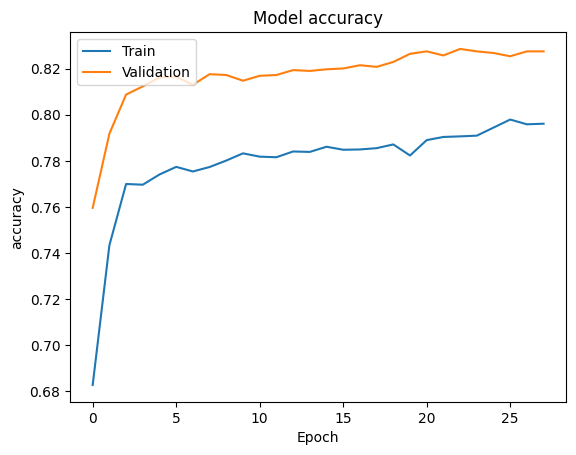

In [11]:

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()
